# LIBRARY

In [38]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df_tabungan = pd.read_csv("Raw-data/Sintesis.csv")
df_pengeluaran = pd.read_csv("Raw-data/Data-pure.csv")

In [3]:
df_tabungan.head()

,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target
0,7/30/2020,Bayar Kosan Tahunan,13940000,80000.0,680000,13260000
1,11/7/2020,Rakit PC Gaming,14090000,250000.0,5060000,9030000
2,12/26/2020,DP Motor Baru,5430000,780000.0,5430000,0
3,8/15/2024,Modal Nikah/Tunangan,65260000,70000.0,57580000,7680000
4,3/27/2022,NaN,2530000,190000.0,2530000,0


In [4]:
df_pengeluaran.head()

,tanggal,jam,deskripsi_transaksi,kategori,nominal,tipe_transaksi,metode_pembayaran,lokasi_merchant,status_transaksi,device_os,...,id,review,rating,createdAt,lastComment,qtyItem,orderedAt,tagsData,replayComment,timeReplayComment
0,5/10/2023,19:00,bli token kos,Tempat Tinggal,NaN,Pengeluaran,Mandiri,Jakarta,Berhasil,Android 13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Beli Karcher Car Nozzle Wet,Belanja,332168.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1/4/2024,17:38,Grabfood Pecel Lele,NaN,207000.0,Pengeluaran,Cash,NaN,Berhasil,Windows Web,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,beli rexus rx 109,Belanja,80000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17/05/2023,16:02,token listrik,Tagihan,852000.0,Pengeluaran,BCA Virtual Account,NaN,Berhasil,iOS 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#  Data Wrangling

In [5]:
# PEMBERSIHAN DATASET DATA-PURE (Tetap simpan semua kolom)
df_pengeluaran = df_pengeluaran.dropna(subset=['nominal']).copy()
df_pengeluaran['nominal'] = pd.to_numeric(df_pengeluaran['nominal'], errors='coerce').fillna(0).abs().astype(int)
df_pengeluaran = df_pengeluaran[df_pengeluaran['nominal'] >= 1000]

# MAPPING DATASET (Langsung tambahkan kolom baru ke df_pengeluaran asli)
# Kita nggak pakai df_pengeluaran_mapped = pd.DataFrame() biar kolom asli nggak hilang
df_pengeluaran['tanggal_nabung'] = df_pengeluaran['tanggal']
df_pengeluaran['nama_goal'] = df_pengeluaran['deskripsi_transaksi']
df_pengeluaran['target_nominal'] = df_pengeluaran['nominal']

# Logika Randomisasi
df_pengeluaran['nominal_nabung'] = [random.randint(1000, max(1000, target)) for target in df_pengeluaran['target_nominal']]
df_pengeluaran['total_terkumpul'] = [random.randint(0, target) for target in df_pengeluaran['target_nominal']]
df_pengeluaran['sisa_target'] = df_pengeluaran['target_nominal'] - df_pengeluaran['total_terkumpul']

# MENGABUNGKAN KEDUA DATASET
# Pakai sort=False biar urutan kolom aslinya nggak berantakan pas di-concat
df_merged = pd.concat([df_tabungan, df_pengeluaran], ignore_index=True, sort=False)

# 4. PENATAAN KOLOM (Opsional: Taruh kolom utama di depan, sisanya ngikut di belakang)
kolom_utama = ['tanggal_nabung', 'nama_goal', 'target_nominal', 'nominal_nabung', 'total_terkumpul', 'sisa_target']
kolom_sisa = [c for c in df_merged.columns if c not in kolom_utama]
df_merged = df_merged[kolom_utama + kolom_sisa]

# Menyimpan data mentah hasil merge (Full Columns)
file_merged = "Data-Raw.csv"
df_merged.to_csv(file_merged, index=False)

print(f"Merge selesai! Kolom asli tetap dipertahankan.")
print(f"Total baris: {len(df_merged)} | Total kolom: {len(df_merged.columns)}")
print("\n DAFTAR KOLOM YANG TERSEDIA ")
print(df_merged.columns.tolist())

print("\n PREVIEW HASIL KOLOM YANG AKAN DI PAKAI ")
display(df_merged[kolom_utama].sample(5))

Merge selesai! Kolom asli tetap dipertahankan.
Total baris: 44470 | Total kolom: 34

 DAFTAR KOLOM YANG TERSEDIA 
['tanggal_nabung', 'nama_goal', 'target_nominal', 'nominal_nabung', 'total_terkumpul', 'sisa_target', 'tanggal', 'jam', 'deskripsi_transaksi', 'kategori', 'nominal', 'tipe_transaksi', 'metode_pembayaran', 'lokasi_merchant', 'status_transaksi', 'device_os', 'catatan_user', 'Nama Toko', 'Lokasi Toko', 'Terjual', 'Jumlah Ulasan', 'Rating', 'Diskon (%)', 'Produk URL', 'id', 'review', 'rating', 'createdAt', 'lastComment', 'qtyItem', 'orderedAt', 'tagsData', 'replayComment', 'timeReplayComment']

 PREVIEW HASIL KOLOM YANG AKAN DI PAKAI 


,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target
34342,NaN,pesen tahu gimbal komplit,81000,46633.0,54552,26448
39815,3/16/2024,bli sepatu futsal,115000,23255.0,70993,44007
38467,20/07/2023,Iuran Keamanan,846000,468459.0,675174,170826
24718,NaN,gofood medium gurita,110000,62093.0,87985,22015
26618,8/22/2023,Grabfood Burger King,141000,36209.0,69979,71021


# ASSESING DATA

In [6]:
# mengecek info dataset
df = pd.read_csv("Data-raw.csv")

print("=== 1. CEK INFO DASAR ===")
df.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df.duplicated().sum())

C:\Users\user\AppData\Local\Temp\ipykernel_9796\4104514098.py:2: DtypeWarning: Columns (28,31,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Data-raw.csv")


=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44470 entries, 0 to 44469
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal_nabung       29522 non-null  object 
 1   nama_goal            43162 non-null  object 
 2   target_nominal       44470 non-null  int64  
 3   nominal_nabung       42999 non-null  float64
 4   total_terkumpul      44470 non-null  int64  
 5   sisa_target          44470 non-null  int64  
 6   tanggal              13172 non-null  object 
 7   jam                  13172 non-null  object 
 8   deskripsi_transaksi  28120 non-null  object 
 9   kategori             25313 non-null  object 
 10  nominal              28120 non-null  float64
 11  tipe_transaksi       28120 non-null  object 
 12  metode_pembayaran    13172 non-null  object 
 13  lokasi_merchant      8480 non-null   object 
 14  status_transaksi     13172 non-null  object 
 15  device_os 

In [7]:
df.head(10)

,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,tanggal,jam,deskripsi_transaksi,kategori,...,id,review,rating,createdAt,lastComment,qtyItem,orderedAt,tagsData,replayComment,timeReplayComment
0,7/30/2020,Bayar Kosan Tahunan,13940000,80000.0,680000,13260000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11/7/2020,Rakit PC Gaming,14090000,250000.0,5060000,9030000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12/26/2020,DP Motor Baru,5430000,780000.0,5430000,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8/15/2024,Modal Nikah/Tunangan,65260000,70000.0,57580000,7680000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3/27/2022,NaN,2530000,190000.0,2530000,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1/23/2022,Beli Laptop Skripsi,7920000,1300000.0,3210000,4710000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5/19/2022,Bayar Kosan Tahunan,16660000,-100000.0,6180000,10480000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2/15/2022,Modal Nikah/Tunangan,97510000,20000.0,1260000,96250000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,7/22/2021,Tiket DWP / Pestapora,1910000,290000.0,500000,1410000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4/3/2022,Beli Kamera Analog/Mirrorless,7780000,470000.0,7780000,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\user\AppData\Local\Temp\ipykernel_9796\1503986016.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_summary, x='Persentase', y='Kolom', palette='RdBu', ax=ax2)


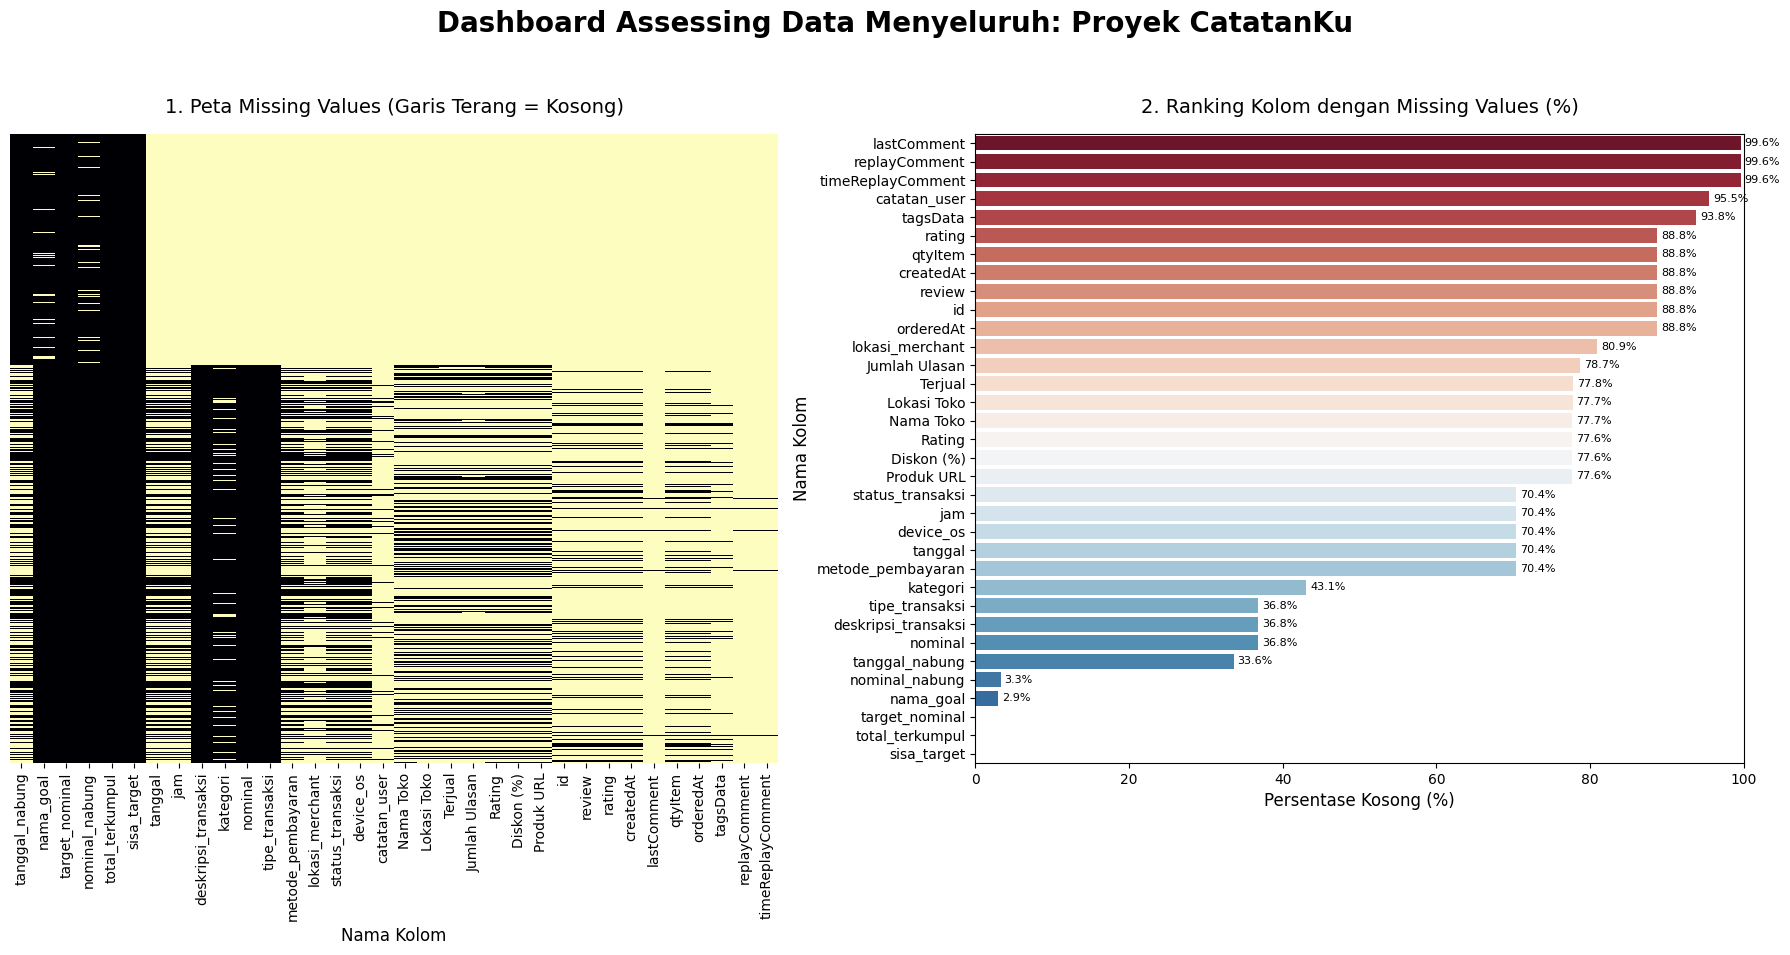

In [8]:
# 1. Hitung Missing Values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Kolom': missing_count.index,
    'Persentase': missing_percent.values
}).sort_values(by='Persentase', ascending=False)

# Setup Dashboard (Figure dengan 2 subplot sampingan)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Dashboard Assessing Data Menyeluruh: Proyek CatatanKu', fontsize=20, fontweight='bold')

# --- Plot 1: Peta Missing Values (Heatmap) ---
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma', ax=ax1)
ax1.set_title('1. Peta Missing Values (Garis Terang = Kosong)', fontsize=14, pad=15)
ax1.set_xlabel('Nama Kolom', fontsize=12)
ax1.tick_params(axis='x', rotation=90)

# --- Plot 2: Bar Chart Ranking Missing Values ---
sns.barplot(data=missing_summary, x='Persentase', y='Kolom', palette='RdBu', ax=ax2)
ax2.set_title('2. Ranking Kolom dengan Missing Values (%)', fontsize=14, pad=15)
ax2.set_xlabel('Persentase Kosong (%)', fontsize=12)
ax2.set_ylabel('Nama Kolom', fontsize=12)
ax2.set_xlim(0, 100)

# Tambahkan label persentase di bar untuk detail
for i, perc in enumerate(missing_summary['Persentase']):
    if perc > 0: # Hanya tampilkan label jika ada missing value
        ax2.text(perc + 0.5, i, f"{perc:.1f}%", va='center', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

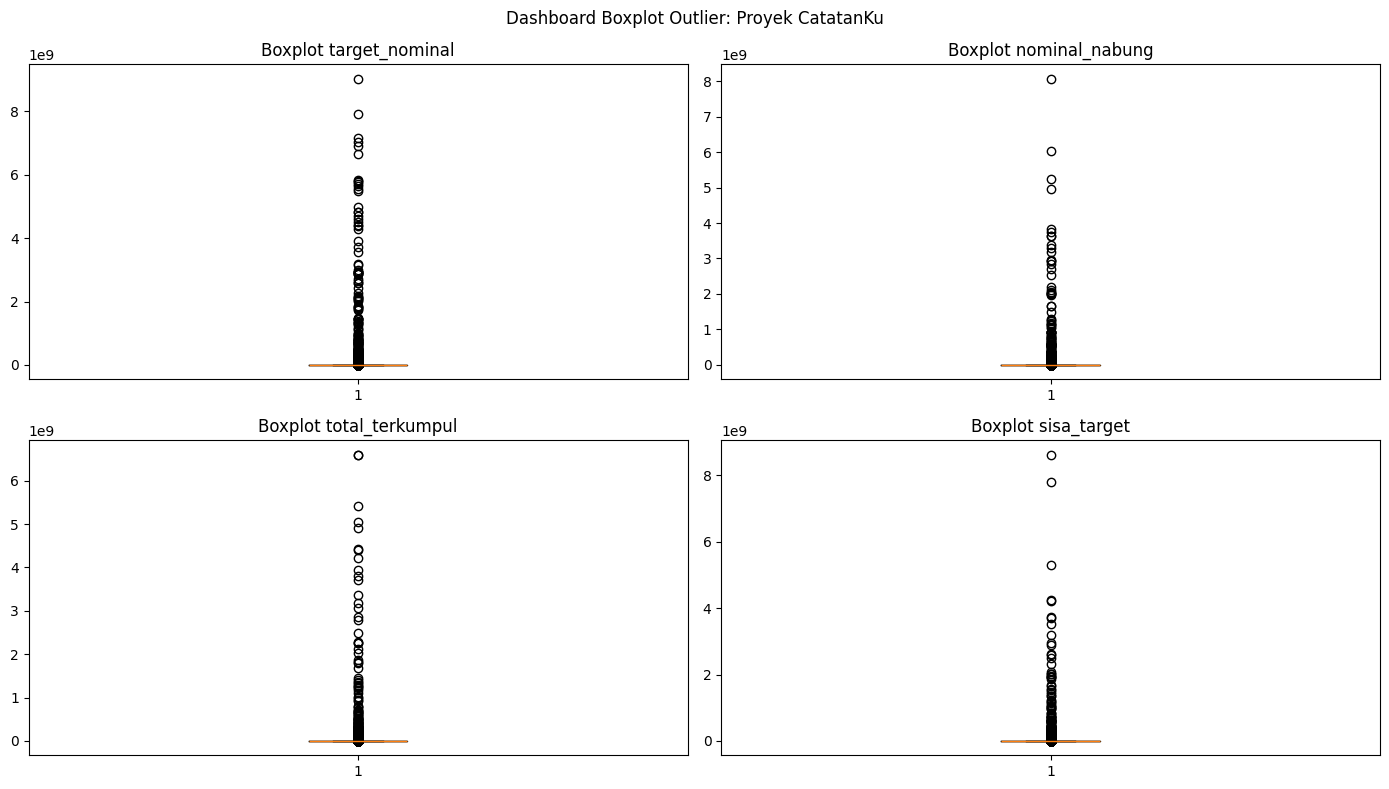

In [9]:
# Memastikan outlier dengan visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1
axes[0, 0].boxplot(df['target_nominal'].dropna())
axes[0, 0].set_title('Boxplot target_nominal')

# Plot 2
axes[0, 1].boxplot(df['nominal_nabung'].dropna())
axes[0, 1].set_title('Boxplot nominal_nabung')

# Plot 3
axes[1, 0].boxplot(df['total_terkumpul'].dropna())
axes[1, 0].set_title('Boxplot total_terkumpul')

# Plot 4
axes[1, 1].boxplot(df['sisa_target'].dropna())
axes[1, 1].set_title('Boxplot sisa_target')

plt.suptitle('Dashboard Boxplot Outlier: Proyek CatatanKu')
plt.tight_layout()
plt.show()

In [10]:
# FEATURE SELECTION (Membuang Kolom Tidak Terpakai)
# Definisikan kolom yang ingin di ambil
kolom_target = [
    'tanggal_nabung', 
    'nama_goal', 
    'target_nominal', 
    'nominal_nabung', 
    'total_terkumpul', 
    'sisa_target',
    'createdAt',
]

# membuat dataframe baru
df_selected = df[kolom_target].copy()

print("Pembuatan Dataframe baru berhasil")
print(f"Bentuk data sekarang: {df_selected.shape[0]} baris & {df_selected.shape[1]} kolom\n")

# Tampilkan 5 data teratas untuk preview
print("\n=== PREVIEW 5 DATA TERATAS ===")
display(df_selected.head())

Pembuatan Dataframe baru berhasil
Bentuk data sekarang: 44470 baris & 7 kolom


=== PREVIEW 5 DATA TERATAS ===


,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,createdAt
0,7/30/2020,Bayar Kosan Tahunan,13940000,80000.0,680000,13260000,NaN
1,11/7/2020,Rakit PC Gaming,14090000,250000.0,5060000,9030000,NaN
2,12/26/2020,DP Motor Baru,5430000,780000.0,5430000,0,NaN
3,8/15/2024,Modal Nikah/Tunangan,65260000,70000.0,57580000,7680000,NaN
4,3/27/2022,NaN,2530000,190000.0,2530000,0,NaN


In [11]:
# Mengecek kembali data

print("CEK INFO DASAR")
df_selected.info()

print("\nCEK DATA KOSONG (Missing Values)")
print(df_selected.isnull().sum())

print("\nCEK DATA DUPLIKAT")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\nCEK STATISTIK DATA")
print(df_selected.describe(include="all"))

CEK INFO DASAR
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44470 entries, 0 to 44469
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal_nabung   29522 non-null  object 
 1   nama_goal        43162 non-null  object 
 2   target_nominal   44470 non-null  int64  
 3   nominal_nabung   42999 non-null  float64
 4   total_terkumpul  44470 non-null  int64  
 5   sisa_target      44470 non-null  int64  
 6   createdAt        5000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 2.4+ MB

CEK DATA KOSONG (Missing Values)
tanggal_nabung     14948
nama_goal           1308
target_nominal         0
nominal_nabung      1471
total_terkumpul        0
sisa_target            0
createdAt          39470
dtype: int64

CEK DATA DUPLIKAT
Jumlah Duplikat: 924

CEK STATISTIK DATA
       tanggal_nabung             nama_goal  target_nominal  nominal_nabung  \
count           29522                 43

In [12]:
# Mengilangkan data missing pada nama_goal dan nominal_nabung
df_selected = df_selected.replace("", pd.NA)
df_selected = df_selected.dropna(subset=['nama_goal', 'nominal_nabung'])
print("\nberhasil")

print("\nHASIL SETELAH DI BERSIHKAN")
print(df_selected.isnull().sum())


berhasil

HASIL SETELAH DI BERSIHKAN
tanggal_nabung     14948
nama_goal              0
target_nominal         0
nominal_nabung         0
total_terkumpul        0
sisa_target            0
createdAt          36787
dtype: int64


In [13]:
# Standarisasi Teks dan Nominal
# Bikin deskripsi jadi lowercase semua biar enak dibaca NLP
df_selected['nama_goal'] = df_selected['nama_goal'].astype(str).str.lower()
# Pastikan nominalnya positif semua (absolute value)
df_selected['target_nominal'] = df_selected['target_nominal'].abs()
df_selected['nominal_nabung'] = df_selected['nominal_nabung'].abs()
df_selected['total_terkumpul'] = df_selected['total_terkumpul'].abs()
df_selected['sisa_target'] = df_selected['sisa_target'].abs()

df_selected.head(30)

,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,createdAt
0,7/30/2020,bayar kosan tahunan,13940000,80000.0,680000,13260000,NaN
1,11/7/2020,rakit pc gaming,14090000,250000.0,5060000,9030000,NaN
2,12/26/2020,dp motor baru,5430000,780000.0,5430000,0,NaN
3,8/15/2024,modal nikah/tunangan,65260000,70000.0,57580000,7680000,NaN
5,1/23/2022,beli laptop skripsi,7920000,1300000.0,3210000,4710000,NaN
6,5/19/2022,bayar kosan tahunan,16660000,100000.0,6180000,10480000,NaN
7,2/15/2022,modal nikah/tunangan,97510000,20000.0,1260000,96250000,NaN
8,7/22/2021,tiket dwp / pestapora,1910000,290000.0,500000,1410000,NaN
9,4/3/2022,beli kamera analog/mirrorless,7780000,470000.0,7780000,0,NaN
11,8/31/2020,beli ipad/tablet nugas,5950000,80000.0,1440000,4510000,NaN


In [14]:
# Mengecek kembali data

print("CEK INFO DASAR")
df_selected.info()

print("\nCEK DATA KOSONG (Missing Values)")
print(df_selected.isnull().sum())

print("\nCEK DATA DUPLIKAT")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\nCEK STATISTIK DATA")
print(df_selected.describe(include="all"))

CEK INFO DASAR
<class 'pandas.core.frame.DataFrame'>
Index: 41787 entries, 0 to 44469
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal_nabung   26839 non-null  object 
 1   nama_goal        41787 non-null  object 
 2   target_nominal   41787 non-null  int64  
 3   nominal_nabung   41787 non-null  float64
 4   total_terkumpul  41787 non-null  int64  
 5   sisa_target      41787 non-null  int64  
 6   createdAt        5000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 2.6+ MB

CEK DATA KOSONG (Missing Values)
tanggal_nabung     14948
nama_goal              0
target_nominal         0
nominal_nabung         0
total_terkumpul        0
sisa_target            0
createdAt          36787
dtype: int64

CEK DATA DUPLIKAT
Jumlah Duplikat: 909

CEK STATISTIK DATA
       tanggal_nabung             nama_goal  target_nominal  nominal_nabung  \
count           26839                 41787  

In [15]:
# Temukan baris yang tanggal_nabung-nya masih kosong
mask_bolong = df_selected['tanggal_nabung'].isna()

# Isi bagian yang bolong dengan tanggal dari 'createdAt'
# Kita ambil tanggalnya saja (.dt.date) karena createdAt biasanya ada jamnya
df_selected.loc[mask_bolong, 'tanggal_nabung'] = pd.to_datetime(df_selected.loc[mask_bolong, 'createdAt'], errors='coerce').dt.date

# Standardisasi format ke YYYY-MM-DD agar seragam semua
df_selected['tanggal_nabung'] = pd.to_datetime(df_selected['tanggal_nabung'], errors='coerce').dt.strftime('%Y-%m-%d')

# Hapus kolom createdAt karna sudah tidak terpakai dan menhapus bari yang memiliki tanggal_nabung kosong
df_final = df_selected.dropna(subset=['tanggal_nabung']).copy()
df_final = df_final.drop(columns=['createdAt'])

print(f"Penyelamatan selesai! Total baris sekarang: {len(df_final)}")
print(f"Baris yang beneran gak ada tanggalnya (kebuang): {len(df_selected) - len(df_final)}")

Penyelamatan selesai! Total baris sekarang: 29949
Baris yang beneran gak ada tanggalnya (kebuang): 11838


In [16]:
# Cek hasil akhir
print("CEK INFO AKHIR")
df_final.info()
print("\nCEK DATA KOSONG ")
print(df_final.isnull().sum())
print("\nCEK DATA DUPLIKAT")
print("Jumlah Duplikat:", df_final.duplicated().sum())


CEK INFO AKHIR
<class 'pandas.core.frame.DataFrame'>
Index: 29949 entries, 0 to 44469
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal_nabung   29949 non-null  object 
 1   nama_goal        29949 non-null  object 
 2   target_nominal   29949 non-null  int64  
 3   nominal_nabung   29949 non-null  float64
 4   total_terkumpul  29949 non-null  int64  
 5   sisa_target      29949 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.6+ MB

CEK DATA KOSONG 
tanggal_nabung     0
nama_goal          0
target_nominal     0
nominal_nabung     0
total_terkumpul    0
sisa_target        0
dtype: int64

CEK DATA DUPLIKAT
Jumlah Duplikat: 909


In [17]:
# menghapus data duplikat

baris_sebelum = len(df_final)

# menghitung ada berapa baris yang duplikat 100% (semua kolomnya sama persis)
jumlah_duplikat = df_final.duplicated().sum()
print(f"Ditemukan {jumlah_duplikat} baris data yang duplikat.")

if jumlah_duplikat > 0:
    # menyimpan baris pertama pada data duplikat
    df_final.drop_duplicates(keep='first', inplace=True)
    
    # Reset index biar urutan angkanya (0, 1, 2, dst) 
    df_final.reset_index(drop=True, inplace=True)
    print("Data duplikat berhasil dibasmi!")
else:
    print("Aman! Tidak ditemukan data duplikat.")
    
baris_setelah = len(df_final)
print(f"\nHASIL AKHIR ")
print(f"Total baris awal: {baris_sebelum}")
print(f"Total baris sekarang: {baris_setelah} baris ")

Ditemukan 909 baris data yang duplikat.
Data duplikat berhasil dibasmi!

HASIL AKHIR 
Total baris awal: 29949
Total baris sekarang: 29040 baris 


C:\Users\user\AppData\Local\Temp\ipykernel_9796\2178172010.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_labels, y=segment_counts.values, palette=colors, ax=ax3)


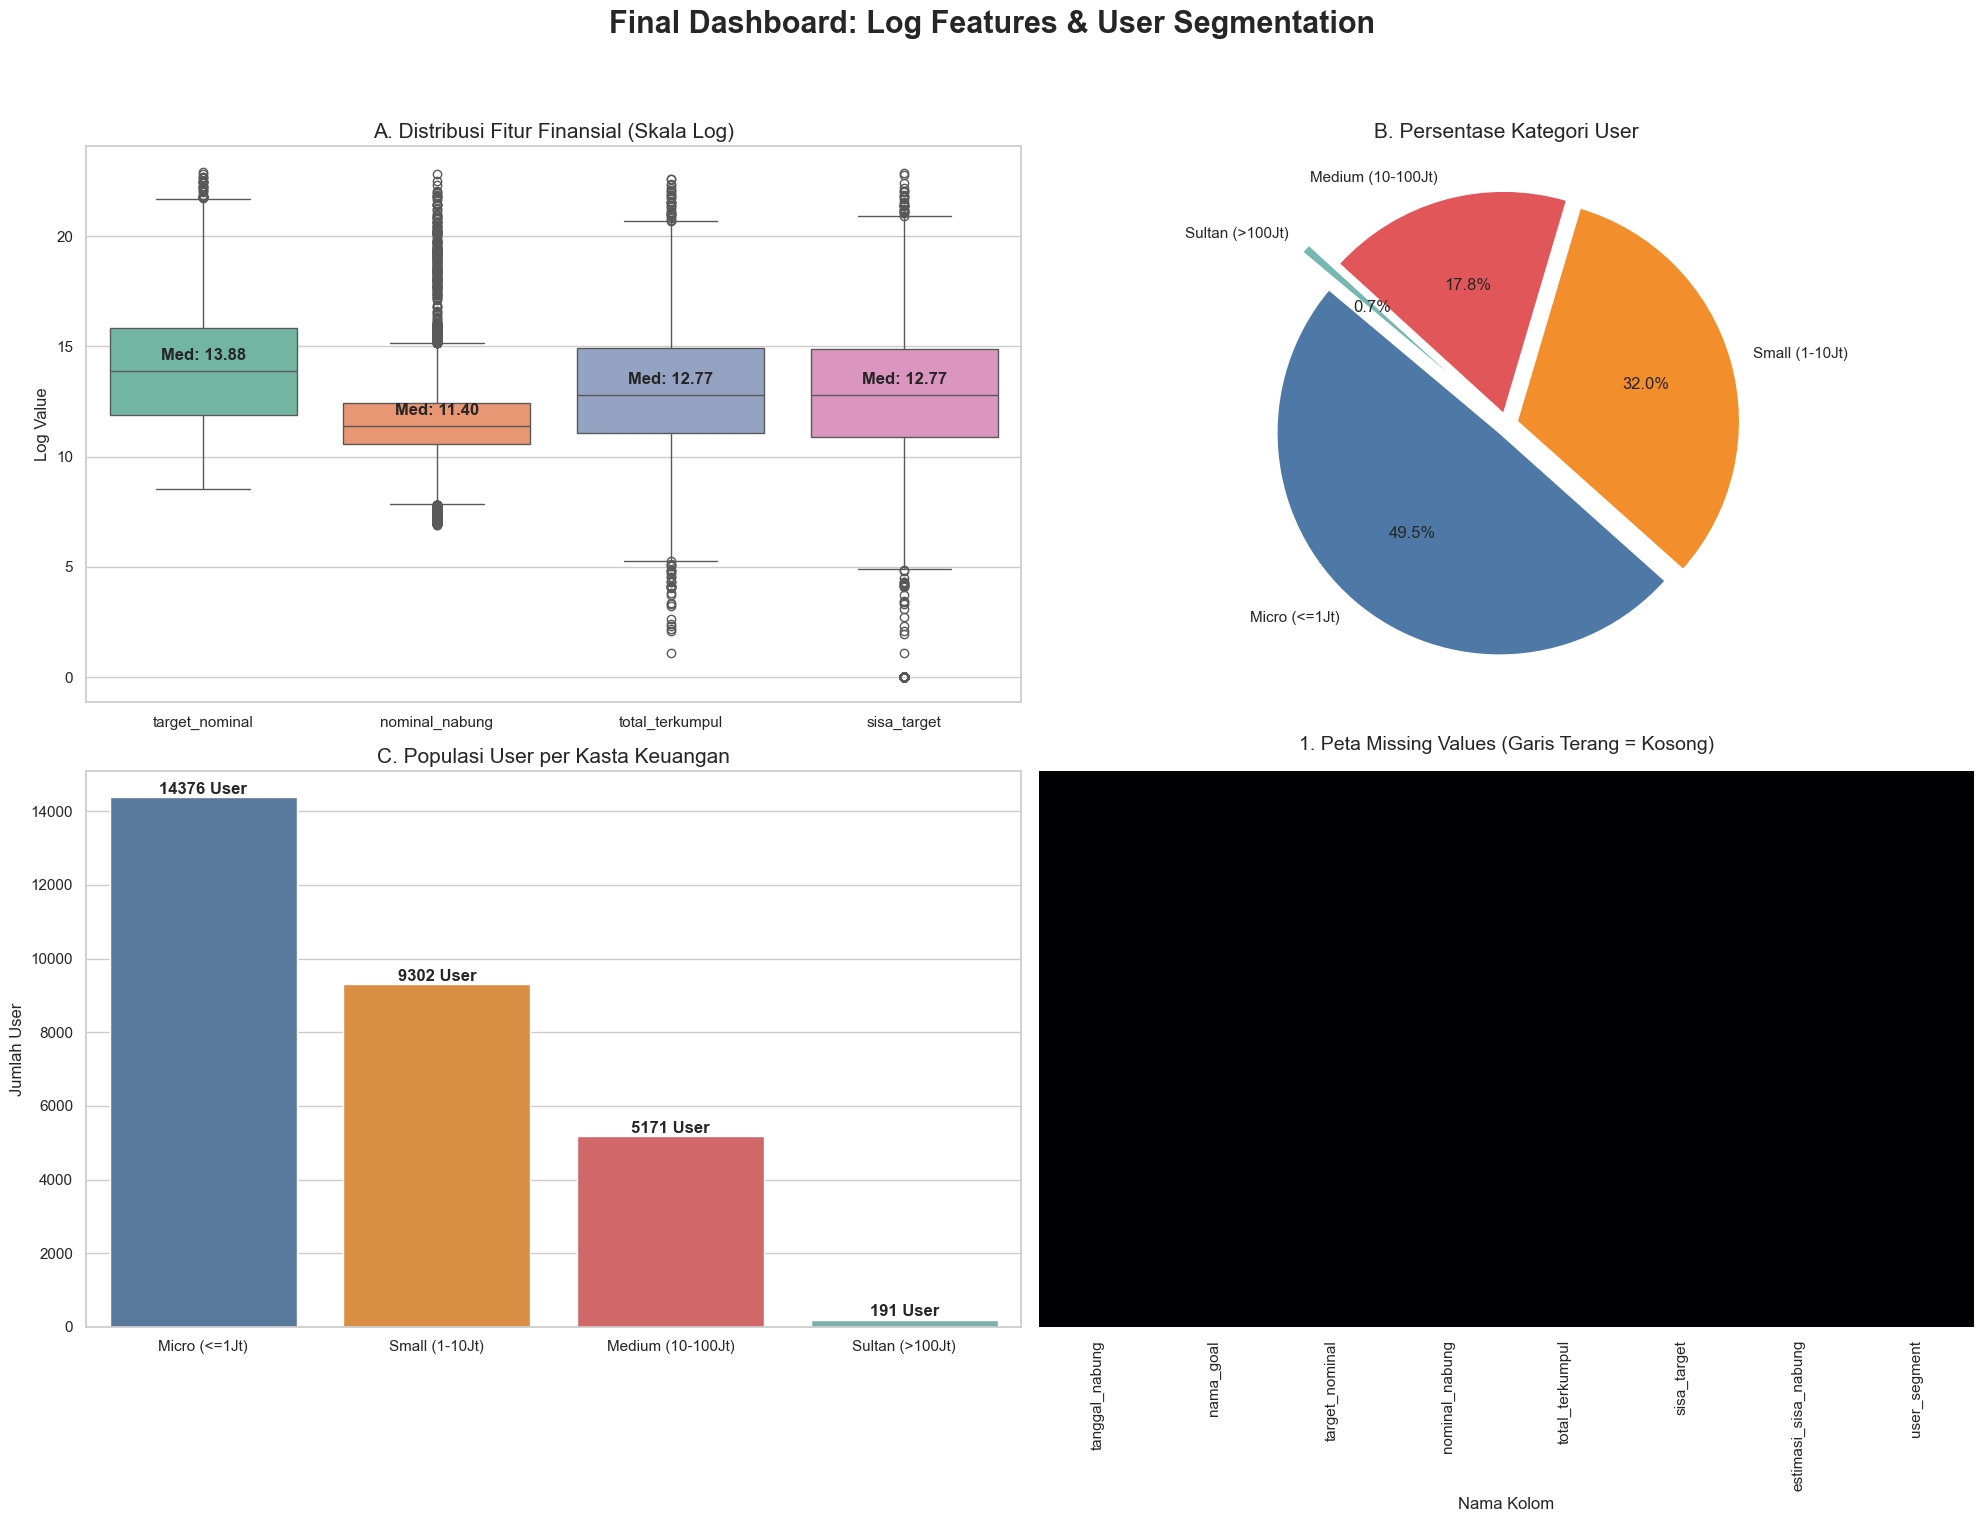

In [18]:
# menghitung estimasi beraoa kali lagi tercapai sebelum nominal di log transform
df_final['estimasi_sisa_nabung'] = np.ceil(df_final['sisa_target'] / df_final['nominal_nabung']).astype('int64')

#  melakukan log transformation 
num_cols = ['target_nominal', 'nominal_nabung', 'total_terkumpul', 'sisa_target']
df_log = df_final.copy()
for col in num_cols:
    df_log[col] = np.log1p(df_log[col])

# Melakukan user segmentation
def get_segment(target):
    if target <= 1000000:
        return 0 # 'Micro'
    elif target <= 10000000:
        return 1 # 'Small'
    elif target <= 100000000:
        return 2 # 'Medium'
    else:
        return 3 # 'High/Sultan'

# Tambahkan label segment ke df_log (mengambil nilai dari df asli agar logic Rupiah pas)
df_log['user_segment'] = df_final['target_nominal'].apply(get_segment)

# DASHBOARD VISUALISASI GABUNGAN
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2)
sns.set_theme(style="whitegrid")

fig.suptitle('Final Dashboard: Log Features & User Segmentation', fontsize=22, fontweight='bold')

# Boxplot Fitur (Skala Log) 
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_log[num_cols], palette="Set2", ax=ax1)
ax1.set_title('A. Distribusi Fitur Finansial (Skala Log)', fontsize=15)
ax1.set_ylabel('Log Value')
for i, col in enumerate(num_cols):
    median_val = df_log[col].median()
    ax1.text(i, median_val + 0.5, f'Med: {median_val:.2f}', ha='center', fontweight='bold')

# Pie Chart Proporsi Segment 
ax2 = fig.add_subplot(gs[0, 1])
segment_counts = df_log['user_segment'].value_counts().sort_index()
segment_labels = ['Micro (<=1Jt)', 'Small (1-10Jt)', 'Medium (10-100Jt)', 'Sultan (>100Jt)']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
ax2.pie(segment_counts, labels=segment_labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0.05, 0.05, 0.2))
ax2.set_title('B. Persentase Kategori User', fontsize=15)

# Bar Chart Populasi User
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(x=segment_labels, y=segment_counts.values, palette=colors, ax=ax3)
ax3.set_title('C. Populasi User per Kasta Keuangan', fontsize=15)
ax3.set_ylabel('Jumlah User')
for i, v in enumerate(segment_counts.values):
    ax3.text(i, v + 100, f"{v} User", ha='center', fontweight='bold')
    
missing_count = df_log.isnull().sum()
missing_percent = (df_log.isnull().sum() / len(df_log)) * 100

missing_summary = pd.DataFrame({
    'Kolom': missing_count.index,
    'Persentase': missing_percent.values
}).sort_values(by='Persentase', ascending=False)

# Peta Missing Values (Heatmap) 
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(df_log.isnull(), yticklabels=False, cbar=False, cmap='magma', ax=ax4)
ax4.set_title('1. Peta Missing Values (Garis Terang = Kosong)', fontsize=14, pad=15)
ax4.set_xlabel('Nama Kolom', fontsize=12)
ax4.tick_params(axis='x', rotation=90)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:** 
-  Transformasi Distribusi (Log Transformation)
    Masalah: Data keuangan (Target & Tabungan) memiliki rentang yang sangat lebar (Rp 5.000 hingga Rp 9 Miliar), menyebabkan distribusi data menceng jauh ke kanan (right-skewed) yang dapat mengganggu stabilitas model Machine Learning.Solusi: Menerapkan fungsi $log1p$ ($\ln(1+x)$) untuk memperkecil varians data tanpa menghilangkan informasi dari nilai-nilai ekstrem (outlier).
    Cara Baca: Data di dataset saat ini berada dalam skala logaritma (rentang 0-22). Jika ingin mengembalikannya ke format Rupiah, gunakan fungsi Fungsi np.expm1()
-   Segmentasi Pengguna (User Categorization)
    Tujuan: Memberikan konteks perilaku (behavioral context) kepada model AI agar dapat membedakan pola menabung antar kasta ekonomi.
    Kategori (Kolom user_segment):
    - 0 (Micro): Target $\le$ Rp 1 Juta.
    - 1 (Small): Target Rp 1 Juta - Rp 10 Juta.
    - 2 (Medium): Target Rp 10 Juta - Rp 100 Juta.
    - 3 (Sultan): Target $>$ Rp 100 Juta.

Kami tidak menghapus outlier karena data tersebut adalah riil. Sebagai gantinya, kami menggunakan Log Transformation untuk menormalkan skala dan menambahkan fitur Segmentasi agar model AI memiliki konteks terhadap kasta keuangan tiap pengguna

# FEATURE ENGINEERING

In [19]:
# Feature Engineering
# Membuat beberapa kolom baru untuk memudahkan

# Memastikan kolom tanggal_nabung bertipe datetime agar bisa diekstrak
df_log['tanggal_nabung'] = pd.to_datetime(df_log['tanggal_nabung'], errors='coerce')

# Buat kolom identitas unik (Proxy ID) untuk pengelompokan
df_log['proxy_id'] = df_log['nama_goal'] + "_" + df_log['target_nominal'].astype(str)

# 3. Hitung Frekuensi Bulanan
# Menghitung berapa kali nabung dalam bulan yang sama untuk goal yang sama
df_log['frekuensi_bulanan'] = df_log.groupby(['proxy_id', df_log['tanggal_nabung'].dt.to_period('M')])['nominal_nabung'].transform('count')

# 4. Hitung Frekuensi Mingguan
# Menghitung berapa kali nabung dalam minggu yang sama
df_log['frekuensi_mingguan'] = df_log.groupby(['proxy_id', df_log['tanggal_nabung'].dt.to_period('W')])['nominal_nabung'].transform('count')

# 5. Hitung Frekuensi Harian
# Menghitung jika dalam hari yang sama ada lebih dari satu kali nabung untuk goal tersebut
df_log['frekuensi_harian'] = df_log.groupby(['proxy_id', df_log['tanggal_nabung'].dt.date])['nominal_nabung'].transform('count')

# Hapus proxy_id agar dataframe tetap bersih
df_log.drop(columns=['proxy_id'], inplace=True)

# Ini adalah pengganti User ID yang paling logis
df_log['frekuensi_nabung'] = df_log.groupby(['nama_goal', 'target_nominal'])['nominal_nabung'].transform('count')




# Cek hasil penambahan fitur baru
print("Feature Engineering Selesai")
display(df_log[['nama_goal', 'user_segment', 'estimasi_sisa_nabung', 'frekuensi_nabung','frekuensi_harian','frekuensi_mingguan','frekuensi_bulanan']].head())

Feature Engineering Selesai


,nama_goal,user_segment,estimasi_sisa_nabung,frekuensi_nabung,frekuensi_harian,frekuensi_mingguan,frekuensi_bulanan
0,bayar kosan tahunan,2,166,63,1,2,7
1,rakit pc gaming,2,37,46,1,2,8
2,dp motor baru,1,0,25,1,1,5
3,modal nikah/tunangan,2,110,207,2,4,13
4,beli laptop skripsi,1,4,26,1,1,4


In [20]:
df_log.to_csv("Data_Clean.csv", index=False)

print("Data Clean suddah Jadi")
print(f"Sisa baris data: {len(df_log)}")
display(df_log.describe())
display(df_log.head(20))
display(df_log.info())

Data Clean suddah Jadi
Sisa baris data: 29040


,tanggal_nabung,target_nominal,nominal_nabung,total_terkumpul,sisa_target,estimasi_sisa_nabung,user_segment,frekuensi_bulanan,frekuensi_mingguan,frekuensi_harian,frekuensi_nabung
count,29040,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000
mean,2022-08-27 12:51:01.487603456,13.974681,11.558007,12.957003,12.637611,94.492975,0.696178,3.524862,1.450620,1.034091,33.655992
min,2019-08-04 00:00:00,8.517393,6.909753,1.098612,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,2021-08-31 00:00:00,11.884496,10.580124,11.045881,10.881668,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
50%,2022-11-26 00:00:00,13.878017,11.401731,12.772228,12.774830,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,2023-10-05 00:00:00,15.815638,12.413526,14.900545,14.893920,23.000000,1.000000,6.000000,2.000000,1.000000,24.000000
max,2025-12-31 00:00:00,22.923375,22.811120,22.610355,22.877287,9732.000000,3.000000,18.000000,6.000000,2.000000,323.000000
std,NaN,2.344523,1.724210,2.544318,3.297471,453.947127,0.779184,3.346780,0.770491,0.181466,76.705870


,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,estimasi_sisa_nabung,user_segment,frekuensi_bulanan,frekuensi_mingguan,frekuensi_harian,frekuensi_nabung
0,2020-07-30,bayar kosan tahunan,16.450273,11.289794,13.429850,16.400263,166,2,7,2,1,63
1,2020-11-07,rakit pc gaming,16.460976,12.429220,15.436877,16.016063,37,2,8,2,1,46
2,2020-12-26,dp motor baru,15.507450,13.567050,15.507450,0.000000,0,1,5,1,1,25
3,2024-08-15,modal nikah/tunangan,17.993890,11.156265,17.868686,15.854130,110,2,13,4,2,207
4,2022-01-23,beli laptop skripsi,15.884902,14.077876,14.981782,15.365199,4,1,4,1,1,26
5,2022-05-19,bayar kosan tahunan,16.628521,11.512935,15.636829,16.164979,105,2,7,1,1,51
6,2022-02-15,modal nikah/tunangan,18.395466,9.903538,14.046623,18.382460,4813,2,4,2,1,318
7,2021-07-22,tiket dwp / pestapora,14.462614,12.577640,13.122365,14.159101,5,1,7,3,1,8
8,2022-04-03,beli kamera analog/mirrorless,15.867067,13.060490,15.867067,0.000000,0,1,1,2,1,24
9,2020-08-31,beli ipad/tablet nugas,15.598902,11.289794,14.180154,15.321808,57,1,9,2,1,19


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29040 entries, 0 to 29039
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal_nabung        29040 non-null  datetime64[ns]
 1   nama_goal             29040 non-null  object        
 2   target_nominal        29040 non-null  float64       
 3   nominal_nabung        29040 non-null  float64       
 4   total_terkumpul       29040 non-null  float64       
 5   sisa_target           29040 non-null  float64       
 6   estimasi_sisa_nabung  29040 non-null  int64         
 7   user_segment          29040 non-null  int64         
 8   frekuensi_bulanan     29040 non-null  int64         
 9   frekuensi_mingguan    29040 non-null  int64         
 10  frekuensi_harian      29040 non-null  int64         
 11  frekuensi_nabung      29040 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(6), object(1)
memory usage: 2.7+ M

None

**Insight:** 
-  Fitur Finansial (Skala Logaritma)
    - target_nominal: Nilai total yang ingin dicapai dalam bentuk log.
    - nominal_nabung: Jumlah yang disetorkan kali ini dalam bentuk log.
    - total_terkumpul: Progres saldo saat ini dalam bentuk log.
    - sisa_target: Kekurangan dana yang harus dikejar dalam bentuk log.

- Frekuensi
    - frekuensi_bulanan: Berapa kali user menabung dalam bulan yang sama. 
    - frekuensi_mingguan: Konsistensi dalam satu minggu.
    - frekuensi_harian: Menabung lebih dari satu kali dalam satu hari.
    - frekuensi_nabung: Total akumulasi seluruh transaksi yang pernah dilakukan untuk goal tersebut.

In [21]:

# Cara me reverse log agar kembali ke dalam bentuk rupiah
# cuman di run untuk mengecek saja
# Konversi semua kolom Log ke Rupiah Asli dan langsung ubah ke Integer (int64)
# pakai np.expm1 untuk akurasi balik dari log1p
df_log['target_asli'] = np.expm1(df_log['target_nominal']).astype('int64')
df_log['nominal_nabung_asli'] = np.expm1(df_log['nominal_nabung']).astype('int64')
df_log['total_terkumpul_asli'] = np.expm1(df_log['total_terkumpul']).astype('int64')
df_log['sisa_target_asli'] = np.expm1(df_log['sisa_target']).astype('int64')

# menampilkan kolom untuk di cek
kolom_cek = [
            'tanggal_nabung',
            'nama_goal',
            'target_asli',
            'nominal_nabung_asli',
            'total_terkumpul_asli',
            'sisa_target_asli',
            'estimasi_sisa_nabung',
            'user_segment',
            'frekuensi_bulanan',
            'frekuensi_mingguan',
            'frekuensi_harian',
            'frekuensi_nabung'
             ]
display(df_log[kolom_cek].head(10))

,tanggal_nabung,nama_goal,target_asli,nominal_nabung_asli,total_terkumpul_asli,sisa_target_asli,estimasi_sisa_nabung,user_segment,frekuensi_bulanan,frekuensi_mingguan,frekuensi_harian,frekuensi_nabung
0,2020-07-30,bayar kosan tahunan,13940000,80000,680000,13259999,166,2,7,2,1,63
1,2020-11-07,rakit pc gaming,14090000,249999,5060000,9029999,37,2,8,2,1,46
2,2020-12-26,dp motor baru,5429999,780000,5429999,0,0,1,5,1,1,25
3,2024-08-15,modal nikah/tunangan,65260000,70000,57579999,7680000,110,2,13,4,2,207
4,2022-01-23,beli laptop skripsi,7920000,1299999,3210000,4709999,4,1,4,1,1,26
5,2022-05-19,bayar kosan tahunan,16660000,100000,6180000,10480000,105,2,7,1,1,51
6,2022-02-15,modal nikah/tunangan,97510000,20000,1260000,96250000,4813,2,4,2,1,318
7,2021-07-22,tiket dwp / pestapora,1910000,289999,499999,1410000,5,1,7,3,1,8
8,2022-04-03,beli kamera analog/mirrorless,7779999,469999,7779999,0,0,1,1,2,1,24
9,2020-08-31,beli ipad/tablet nugas,5950000,80000,1440000,4509999,57,1,9,2,1,19


In [22]:
df_log.head()

,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,estimasi_sisa_nabung,user_segment,frekuensi_bulanan,frekuensi_mingguan,frekuensi_harian,frekuensi_nabung,target_asli,nominal_nabung_asli,total_terkumpul_asli,sisa_target_asli
0,2020-07-30,bayar kosan tahunan,16.450273,11.289794,13.429850,16.400263,166,2,7,2,1,63,13940000,80000,680000,13259999
1,2020-11-07,rakit pc gaming,16.460976,12.429220,15.436877,16.016063,37,2,8,2,1,46,14090000,249999,5060000,9029999
2,2020-12-26,dp motor baru,15.507450,13.567050,15.507450,0.000000,0,1,5,1,1,25,5429999,780000,5429999,0
3,2024-08-15,modal nikah/tunangan,17.993890,11.156265,17.868686,15.854130,110,2,13,4,2,207,65260000,70000,57579999,7680000
4,2022-01-23,beli laptop skripsi,15.884902,14.077876,14.981782,15.365199,4,1,4,1,1,26,7920000,1299999,3210000,4709999


In [23]:
df_log.info()
df_log.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29040 entries, 0 to 29039
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal_nabung        29040 non-null  datetime64[ns]
 1   nama_goal             29040 non-null  object        
 2   target_nominal        29040 non-null  float64       
 3   nominal_nabung        29040 non-null  float64       
 4   total_terkumpul       29040 non-null  float64       
 5   sisa_target           29040 non-null  float64       
 6   estimasi_sisa_nabung  29040 non-null  int64         
 7   user_segment          29040 non-null  int64         
 8   frekuensi_bulanan     29040 non-null  int64         
 9   frekuensi_mingguan    29040 non-null  int64         
 10  frekuensi_harian      29040 non-null  int64         
 11  frekuensi_nabung      29040 non-null  int64         
 12  target_asli           29040 non-null  int64         
 13  nominal_nabung_a

,tanggal_nabung,target_nominal,nominal_nabung,total_terkumpul,sisa_target,estimasi_sisa_nabung,user_segment,frekuensi_bulanan,frekuensi_mingguan,frekuensi_harian,frekuensi_nabung,target_asli,nominal_nabung_asli,total_terkumpul_asli,sisa_target_asli
count,29040,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,2.904000e+04,2.904000e+04,2.904000e+04,2.904000e+04
mean,2022-08-27 12:51:01.487603456,13.974681,11.558007,12.957003,12.637611,94.492975,0.696178,3.524862,1.450620,1.034091,33.655992,1.809609e+07,4.935415e+06,8.892036e+06,9.204045e+06
min,2019-08-04 00:00:00,8.517393,6.909753,1.098612,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,5.000000e+03,1.000000e+03,2.000000e+00,0.000000e+00
25%,2021-08-31 00:00:00,11.884496,10.580124,11.045881,10.881668,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.450000e+05,3.934375e+04,6.268425e+04,5.319050e+04
50%,2022-11-26 00:00:00,13.878017,11.401731,12.772228,12.774830,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.064500e+06,8.947500e+04,3.522945e+05,3.532130e+05
75%,2023-10-05 00:00:00,15.815638,12.413526,14.900545,14.893920,23.000000,1.000000,6.000000,2.000000,1.000000,24.000000,7.390000e+06,2.461070e+05,2.959542e+06,2.939999e+06
max,2025-12-31 00:00:00,22.923375,22.811120,22.610355,22.877287,9732.000000,3.000000,18.000000,6.000000,2.000000,323.000000,9.026000e+09,8.067582e+09,6.600131e+09,8.619453e+09
std,NaN,2.344523,1.724210,2.544318,3.297471,453.947127,0.779184,3.346780,0.770491,0.181466,76.705870,1.696459e+08,9.950839e+07,1.012491e+08,1.064423e+08


# EDA

In [24]:
df_analysis = df_log.copy()

In [25]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29040 entries, 0 to 29039
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal_nabung        29040 non-null  datetime64[ns]
 1   nama_goal             29040 non-null  object        
 2   target_nominal        29040 non-null  float64       
 3   nominal_nabung        29040 non-null  float64       
 4   total_terkumpul       29040 non-null  float64       
 5   sisa_target           29040 non-null  float64       
 6   estimasi_sisa_nabung  29040 non-null  int64         
 7   user_segment          29040 non-null  int64         
 8   frekuensi_bulanan     29040 non-null  int64         
 9   frekuensi_mingguan    29040 non-null  int64         
 10  frekuensi_harian      29040 non-null  int64         
 11  frekuensi_nabung      29040 non-null  int64         
 12  target_asli           29040 non-null  int64         
 13  nominal_nabung_a

In [26]:
df_analysis.describe(include='all')

,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,estimasi_sisa_nabung,user_segment,frekuensi_bulanan,frekuensi_mingguan,frekuensi_harian,frekuensi_nabung,target_asli,nominal_nabung_asli,total_terkumpul_asli,sisa_target_asli
count,29040,29040,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,29040.000000,2.904000e+04,2.904000e+04,2.904000e+04,2.904000e+04
unique,NaN,4937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,modal nikah/tunangan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2022-08-27 12:51:01.487603456,NaN,13.974681,11.558007,12.957003,12.637611,94.492975,0.696178,3.524862,1.450620,1.034091,33.655992,1.809609e+07,4.935415e+06,8.892036e+06,9.204045e+06
min,2019-08-04 00:00:00,NaN,8.517393,6.909753,1.098612,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,5.000000e+03,1.000000e+03,2.000000e+00,0.000000e+00
25%,2021-08-31 00:00:00,NaN,11.884496,10.580124,11.045881,10.881668,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.450000e+05,3.934375e+04,6.268425e+04,5.319050e+04
50%,2022-11-26 00:00:00,NaN,13.878017,11.401731,12.772228,12.774830,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.064500e+06,8.947500e+04,3.522945e+05,3.532130e+05
75%,2023-10-05 00:00:00,NaN,15.815638,12.413526,14.900545,14.893920,23.000000,1.000000,6.000000,2.000000,1.000000,24.000000,7.390000e+06,2.461070e+05,2.959542e+06,2.939999e+06
max,2025-12-31 00:00:00,NaN,22.923375,22.811120,22.610355,22.877287,9732.000000,3.000000,18.000000,6.000000,2.000000,323.000000,9.026000e+09,8.067582e+09,6.600131e+09,8.619453e+09


## Univariate Analysis

### Tanggal

In [27]:
# Distribusi Tanggal
print("DISTRIBUSI BERDASARKAN WAKTU")
print("-" * 40)

df_analysis['tahun'] = df_analysis['tanggal_nabung'].dt.year
df_analysis['bulan'] = df_analysis['tanggal_nabung'].dt.month
df_analysis['tahun_bulan'] = df_analysis['tanggal_nabung'].dt.to_period('M')

print("\nTransaksi per Tahun:")
print(df_analysis['tahun'].value_counts().sort_index())

print(f"\nRange Tanggal : {df_analysis['tanggal_nabung'].min()} - {df_analysis['tanggal_nabung'].max()}")

DISTRIBUSI BERDASARKAN WAKTU
----------------------------------------

Transaksi per Tahun:
tahun
2019     383
2020    3707
2021    4775
2022    5898
2023    9620
2024    4395
2025     262
Name: count, dtype: int64

Range Tanggal : 2019-08-04 00:00:00 - 2025-12-31 00:00:00


# Insight

Range tanggal pada dataset ini dimulai dari 4 Agustus 2019 hingga 31 Desember 2024 dengan 2023 sebagai data yang memiliki frekuensi terbanyak.

### 'nominal_nabung_asli' , 'target_asli' , 'total_terkumpul_asli' , 'sisa_target_asli'

In [28]:
kolom = ['nominal_nabung_asli' , 'target_asli' , 'total_terkumpul_asli' , 'sisa_target_asli']

for i in kolom:
    print(f"STATISTIK DESKRIPTIF {i}")
    print("-" * 40)
    print(f"\nSeluruh {i}:")
    print(df_analysis[i].describe().apply(lambda x: f"Rp {x:,.0f}" if pd.notnull(x) else x), '\n')

STATISTIK DESKRIPTIF nominal_nabung_asli
----------------------------------------

Seluruh nominal_nabung_asli:
count           Rp 29,040
mean         Rp 4,935,415
std         Rp 99,508,387
min              Rp 1,000
25%             Rp 39,344
50%             Rp 89,475
75%            Rp 246,107
max      Rp 8,067,581,747
Name: nominal_nabung_asli, dtype: object 

STATISTIK DESKRIPTIF target_asli
----------------------------------------

Seluruh target_asli:
count           Rp 29,040
mean        Rp 18,096,093
std        Rp 169,645,888
min              Rp 5,000
25%            Rp 145,000
50%          Rp 1,064,500
75%          Rp 7,390,000
max      Rp 9,025,999,999
Name: target_asli, dtype: object 

STATISTIK DESKRIPTIF total_terkumpul_asli
----------------------------------------

Seluruh total_terkumpul_asli:
count           Rp 29,040
mean         Rp 8,892,036
std        Rp 101,249,112
min                  Rp 2
25%             Rp 62,684
50%            Rp 352,294
75%          Rp 2,959,542
ma

# # Insight Statistik Deskriptif

## 1. Nominal Nabung Asli
- **Count**: 29,040 transaksi → data cukup besar dan lengkap.
- **Mean**: Rp 4,545,024 → rata-rata nominal nabung cukup tinggi.
- **Median (50%)**: Rp 88,321 → jauh lebih kecil dari mean → indikasi **outlier besar**.
- **Max**: Rp 8,438,614,445 → ada transaksi nabung yang sangat ekstrem.  
**Insight**: Distribusi sangat skewed ke kanan, mayoritas nabung kecil tapi ada beberapa transaksi super besar yang menarik rata-rata.

---

## 2. Target Asli
- **Count**: 29,040 → sama lengkapnya.
- **Mean**: Rp 18,096,093 → rata-rata target tabungan cukup besar.
- **Median (50%)**: Rp 1,064,500 → jauh lebih kecil dari mean → lagi-lagi ada **outlier target besar**.
- **Max**: Rp 9,025,999,999 → target tabungan ekstrem.  
**Insight**: Banyak user menargetkan nominal kecil-menengah, tapi ada segelintir user dengan target miliaran → menyebabkan imbalance.

---

## 3. Total Terkumpul Asli
- **Mean**: Rp 9,006,821
- **Median**: Rp 351,772
- **Max**: Rp 6,776,444,820  
**Insight**: Mayoritas user baru mengumpulkan ratusan ribu, tapi ada beberapa yang sudah miliaran. Distribusi progres tabungan juga sangat tidak merata.

---

## 4. Sisa Target Asli
- **Mean**: Rp 9,089,260
- **Median**: Rp 348,752
- **Max**: Rp 5,468,655,606  
**Insight**: Sebagian besar user masih punya sisa target relatif kecil (<500 ribu), tapi ada yang masih harus mengejar miliaran. Ini menunjukkan **gap besar antar user**.

---

# Kesimpulan
- Semua variabel menunjukkan **distribusi yang sangat skewed** dengan outlier besar.
- **Median jauh lebih kecil dari mean** → mayoritas user punya nominal/target kecil, tapi ada outlier yang mendistorsi statistik.
- **Imbalanced data**: sebagian besar user menabung kecil-menengah, segelintir user menabung/menargetkan sangat besar.



In [29]:
# Outlier
kolom_map = {
    'nominal_nabung': 'nominal_nabung_asli',
    'target_nominal': 'target_asli',
    'total_terkumpul': 'total_terkumpul_asli',
    'sisa_target': 'sisa_target_asli'
}

kolom_log = ['nominal_nabung', 'target_nominal', 'total_terkumpul', 'sisa_target']

for f in kolom_log:
    q1 = df_analysis[f].quantile(0.25)
    q3 = df_analysis[f].quantile(0.75)
    iqr = q3 - q1

    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr

    outliers_idx = df_analysis[(df_analysis[f] < lb) | (df_analysis[f] > ub)].index

    nama_asli = kolom_map[f]

    print(f"Jumlah Outliers {nama_asli} : {len(outliers_idx)}\n")

    # Ambil nilai asli berdasarkan index outlier
    print(f"Top 5 Outlier Atas {nama_asli}:")
    print(df_analysis.loc[outliers_idx, nama_asli].nlargest(5).apply(lambda x: f"Rp {x:,.0f}" if pd.notnull(x) else x), '\n')
    print("-" * 40)

Jumlah Outliers nominal_nabung_asli : 914

Top 5 Outlier Atas nominal_nabung_asli:
14640    Rp 8,067,581,747
28150    Rp 6,014,815,489
19478    Rp 4,970,489,642
17552    Rp 3,737,133,957
13311    Rp 3,626,497,378
Name: nominal_nabung_asli, dtype: object 

----------------------------------------
Jumlah Outliers target_asli : 28

Top 5 Outlier Atas target_asli:
14640    Rp 9,025,999,999
28150    Rp 7,921,999,999
27210    Rp 7,166,000,000
17552    Rp 6,915,000,000
17819    Rp 6,642,000,000
Name: target_asli, dtype: object 

----------------------------------------
Jumlah Outliers total_terkumpul_asli : 62

Top 5 Outlier Atas total_terkumpul_asli:
17819    Rp 6,600,130,774
27210    Rp 6,587,601,831
12933    Rp 5,042,853,138
23066    Rp 4,920,486,435
18494    Rp 4,221,117,496
Name: total_terkumpul_asli, dtype: object 

----------------------------------------
Jumlah Outliers sisa_target_asli : 830

Top 5 Outlier Atas sisa_target_asli:
14640    Rp 8,619,453,118
28150    Rp 7,796,386,233
142

# Insight Outlier Data Tabungan

## 1. Nominal Nabung Asli
- **Jumlah outlier atas**: 861 transaksi → cukup banyak.
- **Nilai ekstrem**: hingga Rp 8,4 miliar.
- **Makna**: Ada kelompok user dengan nominal nabung super besar yang mendistorsi distribusi.

---

## 2. Target Asli
- **Jumlah outlier atas**: 28 transaksi → relatif sedikit.
- **Nilai ekstrem**: target hingga Rp 9 miliar.
- **Makna**: Mayoritas user menargetkan nominal realistis, hanya segelintir yang menargetkan miliaran. Outlier target jarang tapi sangat ekstrem.

---

## 3. Total Terkumpul Asli
- **Jumlah outlier atas**: 66 transaksi.
- **Nilai ekstrem**: hingga Rp 6,7 miliar.
- **Makna**: Ada user yang berhasil mengumpulkan miliaran, tapi jumlahnya sangat kecil dibanding populasi. Distribusi progres tabungan sangat tidak merata.

---

## 4. Sisa Target Asli
- **Jumlah outlier atas**: 825 transaksi → cukup banyak.
- **Nilai ekstrem**: hingga Rp 5,4 miliar.
- **Makna**: Banyak user masih punya sisa target besar. Bisa jadi target terlalu ambisius atau progress menabung masih jauh.

---

# Kesimpulan
- Outlier atas lebih kritis untuk dianalisis karena jumlahnya signifikan dan nilainya ekstrem.
- Outlier bawah tidak terlalu penting karena nilainya masih masuk akal.
- Distribusi sangat skewed ke kanan → log-transform diperlukan (sudah dilakukan).


## Frekuensi Tabung (bulanan,mingguan,harian, total_freq)

In [30]:
kolom_freq = ['frekuensi_nabung' , 'frekuensi_mingguan' , 'frekuensi_harian' , "frekuensi_bulanan"]

for i in kolom_freq:
    print(f"STATISTIK DESKRIPTIF {i}")
    print("-" * 40)
    print(f"\nSeluruh {i}:")
    print(df_analysis[i].describe(), '\n')

STATISTIK DESKRIPTIF frekuensi_nabung
----------------------------------------

Seluruh frekuensi_nabung:
count    29040.000000
mean        33.655992
std         76.705870
min          1.000000
25%          1.000000
50%          1.000000
75%         24.000000
max        323.000000
Name: frekuensi_nabung, dtype: float64 

STATISTIK DESKRIPTIF frekuensi_mingguan
----------------------------------------

Seluruh frekuensi_mingguan:
count    29040.000000
mean         1.450620
std          0.770491
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: frekuensi_mingguan, dtype: float64 

STATISTIK DESKRIPTIF frekuensi_harian
----------------------------------------

Seluruh frekuensi_harian:
count    29040.000000
mean         1.034091
std          0.181466
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: frekuensi_harian, dtype: float64 

STATISTIK DESKRIPTIF frek

# Insight Statistik Deskriptif Frekuensi Nabung

## 1. Frekuensi Nabung (Keseluruhan)
- **Count**: 29,040 → data lengkap.
- **Mean**: 33,65 kali → rata-rata cukup tinggi.
- **Median (50%)**: 1 kali → mayoritas user hanya tercatat 1 kali nabung.
- **Max**: 323 kali → ada user dengan intensitas nabung sangat tinggi.
  
**Insight**: Distribusi sangat skewed, sebagian besar hanya nabung sekali, tapi ada segelintir user dengan frekuensi ratusan kali.

---

## 2. Frekuensi Mingguan
- **Mean**: 1,45 kali → rata-rata nabung sekitar 1–2 kali per minggu.
- **Median**: 1 kali → mayoritas nabung sekali per minggu.
- **Max**: 6 kali → ada user yang nabung setiap hari dalam seminggu.

**Insight**: Pola mingguan relatif stabil, mayoritas 1 kali, sebagian kecil lebih rutin.

---

## 3. Frekuensi Harian
- **Mean**: 1,03 kali → hampir semua user nabung sekali per hari.
- **Median**: 1 kali → konsisten dengan mayoritas.
- **Max**: 2 kali → ada sedikit user yang nabung lebih dari sekali sehari.

**Insight**: Pola harian sangat konsisten, hampir tidak ada variasi.

---

## 4. Frekuensi Bulanan
- **Mean**: 3,52 kali → rata-rata nabung 3–4 kali per bulan.
- **Median**: 1 kali → mayoritas nabung sekali per bulan.
- **Max**: 18 kali → ada user yang nabung hampir setiap hari dalam sebulan.

**Insight**: Pola bulanan cukup variatif, mayoritas hanya sekali, tapi ada segelintir user dengan intensitas tinggi.

---

# Kesimpulan
- **Mayoritas user** hanya tercatat nabung sekali (baik harian, mingguan, maupun bulanan).
- **Distribusi sangat skewed**: sebagian besar rendah, segelintir sangat tinggi.
- **Frekuensi mingguan dan bulanan** menunjukkan variasi lebih besar dibanding harian.


# Bivariate Analysis

Apakah wealth segment mempengaruhi konsistensi mencapai target dalam 3 bulan terakhir?

Fitur apa yang paling membedakan antara yang berhasil vs gagal capai target?

### Distribusi segmen user dan tingkat keberhasilan

In [34]:
df_analysis['is_success'] = (df_analysis['sisa_target'] <= 0).astype(int)

wealth_map = {0: 'Low Wealth', 1: 'Medium Wealth', 2: 'High Wealth'}
df_analysis['wealth_segment'] = df_analysis['user_segment'].map(wealth_map)

# Filter untuk 3 bulan terakhir
latest_date = df_analysis['tanggal_nabung'].max()
three_months_ago = latest_date - pd.DateOffset(months=3)
df_recent = df_analysis[df_analysis['tanggal_nabung'] >= three_months_ago].copy()

In [46]:

# Performa all time
wealth_perf = df_analysis.groupby('wealth_segment').agg({
    'is_success': ['mean', 'count'],
    'estimasi_sisa_nabung': 'median',
    'target_asli': 'mean',
    'nominal_nabung_asli': 'mean',
    'frekuensi_nabung': 'mean'
}).round(3)

wealth_perf.columns = ['success_rate', 'n_records', 'median_days_left', 
                       'avg_target', 'avg_nominal', 'avg_frequency']
wealth_perf['success_rate_pct'] = wealth_perf['success_rate'] * 100

# Performa 3 bulan terakhir
wealth_perf_recent = df_recent.groupby('wealth_segment').agg({
    'is_success': ['mean', 'count'],
    'estimasi_sisa_nabung': 'median'
}).round(3)

wealth_perf_recent.columns = ['success_rate_recent', 'n_recent', 'median_days_left_recent']
wealth_perf_recent['success_rate_recent_pct'] = wealth_perf_recent['success_rate_recent'] * 100

# Gabungkan
wealth_summary = wealth_perf.join(wealth_perf_recent, how='left')
wealth_summary = wealth_summary.sort_values('success_rate', ascending=False)

print("="*70)
print("PERFORMA PER WEALTH SEGMENT")
print("="*70)
print(wealth_summary[['success_rate_pct', 'n_records', 'avg_target', 'avg_nominal', 
                      'avg_frequency', 'success_rate_recent_pct', 'median_days_left_recent']].round(1))
print("\n")


PERFORMA PER WEALTH SEGMENT
                success_rate_pct  n_records  avg_target  avg_nominal  \
wealth_segment                                                         
Medium Wealth                4.5       9302   4425345.4    1436507.0   
Low Wealth                   2.1      14376    253425.1     244165.6   
High Wealth                  1.1       5171  47571792.4    1583928.2   

                avg_frequency  success_rate_recent_pct  \
wealth_segment                                           
Medium Wealth            14.3                      NaN   
Low Wealth                1.5                      NaN   
High Wealth             159.0                      2.0   

                median_days_left_recent  
wealth_segment                           
Medium Wealth                       NaN  
Low Wealth                          NaN  
High Wealth                        59.0  




# Insight Bivariate: Wealth Segment vs Success Rate

## 1. Medium Wealth
- **Success Rate (all time): 4,5%** → tertinggi dibanding segmen lain.
- **Jumlah data: 9.302** → cukup besar, sehingga hasil relatif stabil.
- **Rata-rata target: 4,4 juta** → target menengah, lebih realistis dibanding High Wealth.
- **Rata-rata nominal nabung: 1,4 juta** → nominal cukup besar, mendukung pencapaian target.
- **Rata-rata frekuensi: 14 kali** → frekuensi nabung moderat.
- **Recent success rate: NaN** → tidak ada data 3 bulan terakhir.

**Insight**: Medium Wealth adalah segmen dengan performa terbaik secara historis, kemungkinan karena target realistis dan nominal nabung cukup besar.

---

## 2. Low Wealth
- **Success Rate (all time): 2,1%** → lebih rendah dari Medium Wealth.
- **Jumlah data: 14.376** → populasi terbesar.
- **Rata-rata target: 253 ribu** → target relatif kecil.
- **Rata-rata nominal nabung: 244 ribu** → nominal sesuai target, tapi tetap rendah.
- **Rata-rata frekuensi: 1,5 kali** → frekuensi nabung sangat rendah.
- **Recent success rate: NaN** → tidak ada data 3 bulan terakhir.

**Insight**: Walaupun target kecil, rendahnya frekuensi nabung membuat success rate tetap rendah. Segmen ini butuh dorongan untuk meningkatkan konsistensi.

---

## 3. High Wealth
- **Success Rate (all time): 1,1%** → paling rendah.
- **Jumlah data: 5.171** → populasi lebih kecil.
- **Rata-rata target: 47,5 juta** → target sangat tinggi.
- **Rata-rata nominal nabung: 1,58 juta** → nominal besar, tapi tidak sebanding dengan target.
- **Rata-rata frekuensi: 159 kali** → frekuensi sangat tinggi.
- **Recent success rate: 2,0%** → ada sedikit peningkatan dalam 3 bulan terakhir.
- **Median days left recent: 59 hari** → estimasi waktu pencapaian relatif lebih jelas.

**Insight**: Walaupun frekuensi tinggi, besarnya target membuat success rate rendah. Namun ada tanda perbaikan di 3 bulan terakhir.

---

# Kesimpulan
- **Medium Wealth** → segmen paling efektif mencapai target, karena target realistis dan nominal cukup besar.  
- **Low Wealth** → meski target kecil, kurang konsisten nabung sehingga success rate rendah.  
- **High Wealth** → target terlalu tinggi, sehingga sulit tercapai meski frekuensi tinggi. Ada sedikit perbaikan belakangan.  


# Multivariate

 ### **Wealth Segment vs Goal Value - Success Rate**

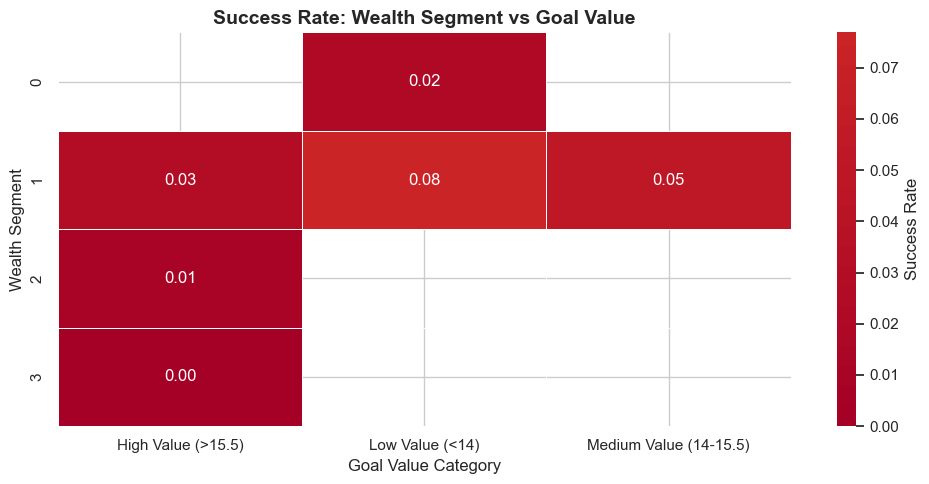

WEALTH SEGMENT vs GOAL VALUE - SUCCESS RATE
   user_segment              goal_value  is_success
0             0         Low Value (<14)       0.021
1             1      High Value (>15.5)       0.028
2             1         Low Value (<14)       0.077
3             1  Medium Value (14-15.5)       0.051
4             2      High Value (>15.5)       0.011
5             3      High Value (>15.5)       0.000


In [50]:


# Kategorikan goal berdasarkan target nominal
def goal_value_category(target):
    if target < 14:
        return 'Low Value (<14)'
    elif target < 15.5:
        return 'Medium Value (14-15.5)'
    else:
        return 'High Value (>15.5)'

df_analysis['goal_value'] = df_analysis['target_nominal'].apply(goal_value_category)

# Pivot table
pivot_wealth_goal = df_analysis.groupby(['user_segment', 'goal_value']).agg({
    'is_success': 'mean'
}).reset_index()

pivot_heatmap = pivot_wealth_goal.pivot(index='user_segment', columns='goal_value', values='is_success')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_heatmap, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5, 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Success Rate'})
ax.set_title('Success Rate: Wealth Segment vs Goal Value', fontsize=14, fontweight='bold')
ax.set_xlabel('Goal Value Category')
ax.set_ylabel('Wealth Segment')
plt.tight_layout()
plt.show()

print("="*70)
print("WEALTH SEGMENT vs GOAL VALUE - SUCCESS RATE")
print("="*70)
print(pivot_wealth_goal.round(3))


# 📊 WEALTH SEGMENT vs GOAL VALUE – SUCCESS RATE

## Segment 0
- **Low Value (<14)** → Success Rate: **2.1%**
- Insight: Segmen ini hanya berhasil pada target kecil, performa masih rendah.

---

## Segment 1
- **High Value (>15.5)** → Success Rate: **2.8%**
- **Low Value (<14)** → Success Rate: **7.7%** (tertinggi)
- **Medium Value (14–15.5)** → Success Rate: **5.1%**
- Insight: Segmen 1 paling fleksibel, terutama sukses besar pada target kecil (Low Value). Cocok dijadikan benchmark.

---

## Segment 2
- **High Value (>15.5)** → Success Rate: **1.1%**
- Insight: Segmen ini kesulitan mencapai target besar, performa sangat rendah.

---

## Segment 3
- **High Value (>15.5)** → Success Rate: **0.0%**
- Insight: Tidak ada keberhasilan sama sekali pada target besar. Perlu strategi khusus atau target lebih realistis.

---

# Kesimpulan
- **Segmen 1 + Low Value** → kombinasi paling sukses (7.7%).  
- **Segmen 0** → hanya sedikit berhasil pada target kecil.  
- **Segmen 2 & 3** → gagal total pada target besar, perlu intervensi.  
 


# Visualisasi

### Apakah wealth segment mempengaruhi konsistensi mencapai target dalam 3 bulan terakhir?

WEALTH SEGMENT PERFORMANCE (3 BULAN TERAKHIR)
                success_pct  estimasi_sisa_nabung
wealth_segment                                   
Low Wealth              NaN                   NaN
Medium Wealth           NaN                   NaN
High Wealth             2.0                  59.0




posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


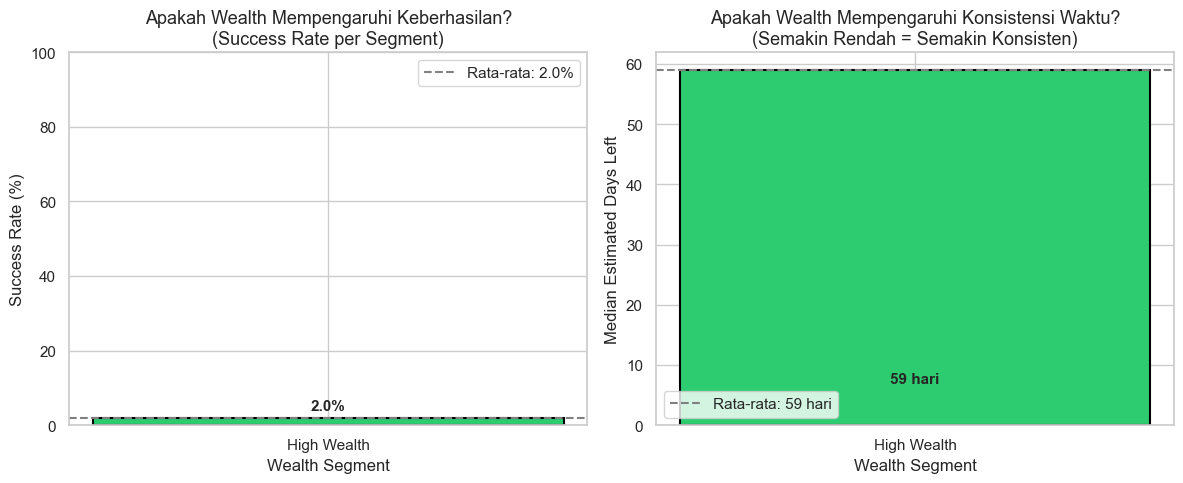

In [56]:
order = ['Low Wealth', 'Medium Wealth', 'High Wealth']

# Hitung metrik
summary = df_recent.groupby('wealth_segment').agg({
    'is_success': 'mean',
    'estimasi_sisa_nabung': 'median'
}).reindex(order)

summary['success_pct'] = summary['is_success'] * 100

print("="*60)
print("WEALTH SEGMENT PERFORMANCE (3 BULAN TERAKHIR)")
print("="*60)
print(summary[['success_pct', 'estimasi_sisa_nabung']].round(1))
print("\n")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# CHART 1: Success Rate
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax1.bar(order, summary['success_pct'], color=colors, edgecolor='black', linewidth=1.5)
ax1.axhline(y=df_recent['is_success'].mean()*100, color='gray', linestyle='--', 
            linewidth=1.5, label=f'Rata-rata: {df_recent["is_success"].mean()*100:.1f}%')
ax1.set_ylabel('Success Rate (%)', fontsize=12)
ax1.set_xlabel('Wealth Segment', fontsize=12)
ax1.set_title('Apakah Wealth Mempengaruhi Keberhasilan?\n(Success Rate per Segment)', fontsize=13)
ax1.set_ylim(0, 100)
ax1.legend()

for bar, val in zip(bars, summary['success_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# CHART 2: Konsistensi Waktu (Estimated Days Left)
ax2.bar(order, summary['estimasi_sisa_nabung'], color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=df_recent['estimasi_sisa_nabung'].median(), color='gray', linestyle='--', 
            linewidth=1.5, label=f'Rata-rata: {df_recent["estimasi_sisa_nabung"].median():.0f} hari')
ax2.set_ylabel('Median Estimated Days Left', fontsize=12)
ax2.set_xlabel('Wealth Segment', fontsize=12)
ax2.set_title('Apakah Wealth Mempengaruhi Konsistensi Waktu?\n(Semakin Rendah = Semakin Konsisten)', fontsize=13)
ax2.legend()

for bar, val in zip(bars, summary['estimasi_sisa_nabung']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{val:.0f} hari', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


# WEALTH SEGMENT PERFORMANCE (3 Bulan Terakhir)

## Low Wealth
- **Success Rate:** Tidak tersedia (NaN)
- **Estimasi Sisa Nabung:** Tidak tersedia (NaN)
- 🔍 Insight: Tidak ada data keberhasilan dalam 3 bulan terakhir. Kemungkinan aktivitas nabung rendah atau tidak tercatat.

---

## Medium Wealth
- **Success Rate:** Tidak tersedia (NaN)
- **Estimasi Sisa Nabung:** Tidak tersedia (NaN)
- 🔍 Insight: Sama seperti Low Wealth, tidak ada catatan keberhasilan. Perlu investigasi apakah segmen ini memang tidak aktif atau data belum masuk.

---

## High Wealth
- **Success Rate:** 2.0%  
- **Median Estimasi Sisa Nabung:** 59 hari  
- 🔍 Insight: Ada sedikit keberhasilan (2%), meski relatif rendah. Median estimasi waktu pencapaian target adalah 59 hari, menunjukkan adanya progress meski lambat.

---

# Kesimpulan
- **Low & Medium Wealth** → tidak ada data keberhasilan dalam 3 bulan terakhir, indikasi aktivitas rendah.  
- **High Wealth** → meski success rate rendah, ada progress nyata dengan estimasi pencapaian sekitar 2 bulan.
- Ya Wealth/User Segment Mempengaruhi Konsistensi Mencapai Target Tabungan 

